# 03 · Training & Clinical Threshold Optimisation
**Deep Residual MLP for Diabetes Risk Prediction (CDC BRFSS 2015, PyTorch)**  
*Sections 8-10* · MSc Data Science project · Dr. Spoorthi H S

**In this notebook**
- AdamW + cosine annealing with early stopping (early stopping at epoch 14 of 60)
- Train / validation / test curve dashboard
- Validation-chosen thresholds: F1-optimal (0.45) and 80%-sensitivity screening (0.35)

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline. Each part builds on objects created earlier (data splits, the trained model, chosen thresholds), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Residual MLP & Depth × Width Ablation](02_model_and_depth_width_ablation.ipynb) · [Evaluation, Explainability & Consistency Audit →](04_evaluation_and_explainability.ipynb)

---

---
## 8. Full Training Pipeline <a id='sec8'></a>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — Full training: best architecture
# ═══════════════════════════════════════════════════════════════
N_EPOCHS  = 60
LR        = 1e-3
WD        = 1e-4
H_DIM     = 512
N_BLOCKS  = 5
DROP      = 0.30

model     = DiabetesDNN(N_FEAT, H_DIM, N_BLOCKS, DROP, 'gelu').to(DEVICE)
loss_fn   = FocalLoss(alpha=0.25, gamma=2.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-6)
stopper   = EarlyStopping(patience=12, path='best_diabetes_dnn.pt')

hist = defaultdict(list)

print(f'Model      : {N_FEAT}→{H_DIM}×{N_BLOCKS}→1   Params={model.n_params():,}')
print(f'Loss       : FocalLoss(α=0.25, γ=2.0)')
print(f'Optimizer  : AdamW  LR={LR}  WD={WD}')
print(f'Schedule   : CosineAnnealing  T_max={N_EPOCHS}')
print('─'*95)
print(f'{"Ep":>4}|{"TrLoss":>9}|{"VlLoss":>9}|{"TrAUC":>7}|{"VlAUC":>7}|{"TrAP":>7}|{"VlAP":>7}|{"TrF1":>7}|{"VlF1":>7}|{"LR":>9}')
print('─'*95)

t0 = time.time()
for ep in range(1, N_EPOCHS+1):
    tr = run_epoch(model, train_loader,      optimizer, loss_fn, DEVICE, training=True)
    vl = run_epoch(model, val_loader,        optimizer, loss_fn, DEVICE, training=False)
    # Evaluate on raw (unsmoted) train set for honest reporting
    tr_eval = run_epoch(model, train_eval_loader, optimizer, loss_fn, DEVICE, training=False)
    scheduler.step()
    lr = optimizer.param_groups[0]['lr']

    for k,v in [
        ('tr_loss',tr['loss']), ('vl_loss',vl['loss']),
        ('tr_auc', tr_eval['auc']), ('vl_auc', vl['auc']),
        ('tr_ap',  tr_eval['ap']),  ('vl_ap',  vl['ap']),
        ('tr_acc', tr_eval['acc']), ('vl_acc', vl['acc']),
        ('tr_f1',  tr_eval['f1']),  ('vl_f1',  vl['f1']),
        ('lr', lr)
    ]: hist[k].append(v)

    if ep%5==0 or ep==1:
        print(f'{ep:>4}|{tr["loss"]:>9.5f}|{vl["loss"]:>9.5f}|'
              f'{tr_eval["auc"]:>7.4f}|{vl["auc"]:>7.4f}|'
              f'{tr_eval["ap"]:>7.4f}|{vl["ap"]:>7.4f}|'
              f'{tr_eval["f1"]:>7.4f}|{vl["f1"]:>7.4f}|{lr:>9.2e}')

    if stopper.step(vl['loss'], model):
        print(f'\n  Early stopping at epoch {ep}')
        break

elapsed = time.time()-t0
print('─'*95)
print(f'\n  Done in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'   Best Val AUC : {max(hist["vl_auc"]):.4f}')
print(f'   Best Val AP  : {max(hist["vl_ap"]):.4f}')
print(f'   Best Val F1  : {max(hist["vl_f1"]):.4f}')

model.load_state_dict(torch.load('best_diabetes_dnn.pt', weights_only=True))
print('  Best checkpoint loaded.')

Model      : 21→512×5→1   Params=2,781,185
Loss       : FocalLoss(α=0.25, γ=2.0)
Optimizer  : AdamW  LR=0.001  WD=0.0001
Schedule   : CosineAnnealing  T_max=60
───────────────────────────────────────────────────────────────────────────────────────────────
  Ep|   TrLoss|   VlLoss|  TrAUC|  VlAUC|   TrAP|   VlAP|   TrF1|   VlF1|       LR
───────────────────────────────────────────────────────────────────────────────────────────────
   1|  0.04624|  0.02980| 0.9072| 0.9021| 0.6884| 0.6757| 0.6050| 0.6016| 9.99e-04
   5|  0.03588|  0.02990| 0.9114| 0.9015| 0.6957| 0.6739| 0.6053| 0.5939| 9.83e-04
  10|  0.03472|  0.03301| 0.9173| 0.8985| 0.7068| 0.6695| 0.6288| 0.6077| 9.33e-04

  Early stopping at epoch 14
───────────────────────────────────────────────────────────────────────────────────────────────

  Done in 1733.8s (28.9 min)
   Best Val AUC : 0.9025
   Best Val AP  : 0.6766
   Best Val F1  : 0.6116
  Best checkpoint loaded.


> **Interpretation.** Training ran on CPU for 28.9 minutes and early stopping (patience 12 on validation loss) halted it at epoch 14 of 60, restoring the best checkpoint. Validation AUC peaks early (0.9025) while training AUC keeps rising, so the model reaches the dataset's ceiling within a few epochs and further epochs only add overfitting risk - consistent with the flat ablation results above.

---
## 9. Training / Validation / Test Curve Dashboard <a id='sec9'></a>

All three splits are tracked and plotted together for **complete transparency**.
- 🔵 **Blue = Training** (on SMOTE-augmented data)  
- 🟠 **Orange = Validation** (real distribution, unseen during training)  
- 🟢 **Green = Test** (real distribution, unseen until final evaluation)  


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — Evaluate test set (needed for test curves)
# ═══════════════════════════════════════════════════════════════
# We collect test metrics at the FINAL epoch for the dashboard
te = run_epoch(model, test_loader, optimizer, loss_fn, DEVICE, training=False)
test_probs  = te['probs']
test_labels = te['labels']

print(f'Test AUC : {te["auc"]:.4f}')
print(f'Test AP  : {te["ap"]:.4f}')
print(f'Test Acc : {te["acc"]:.4f}')
print(f'Test F1  : {te["f1"]:.4f}')

Test AUC : 0.9015
Test AP  : 0.6703
Test Acc : 0.9010
Test F1  : 0.5936


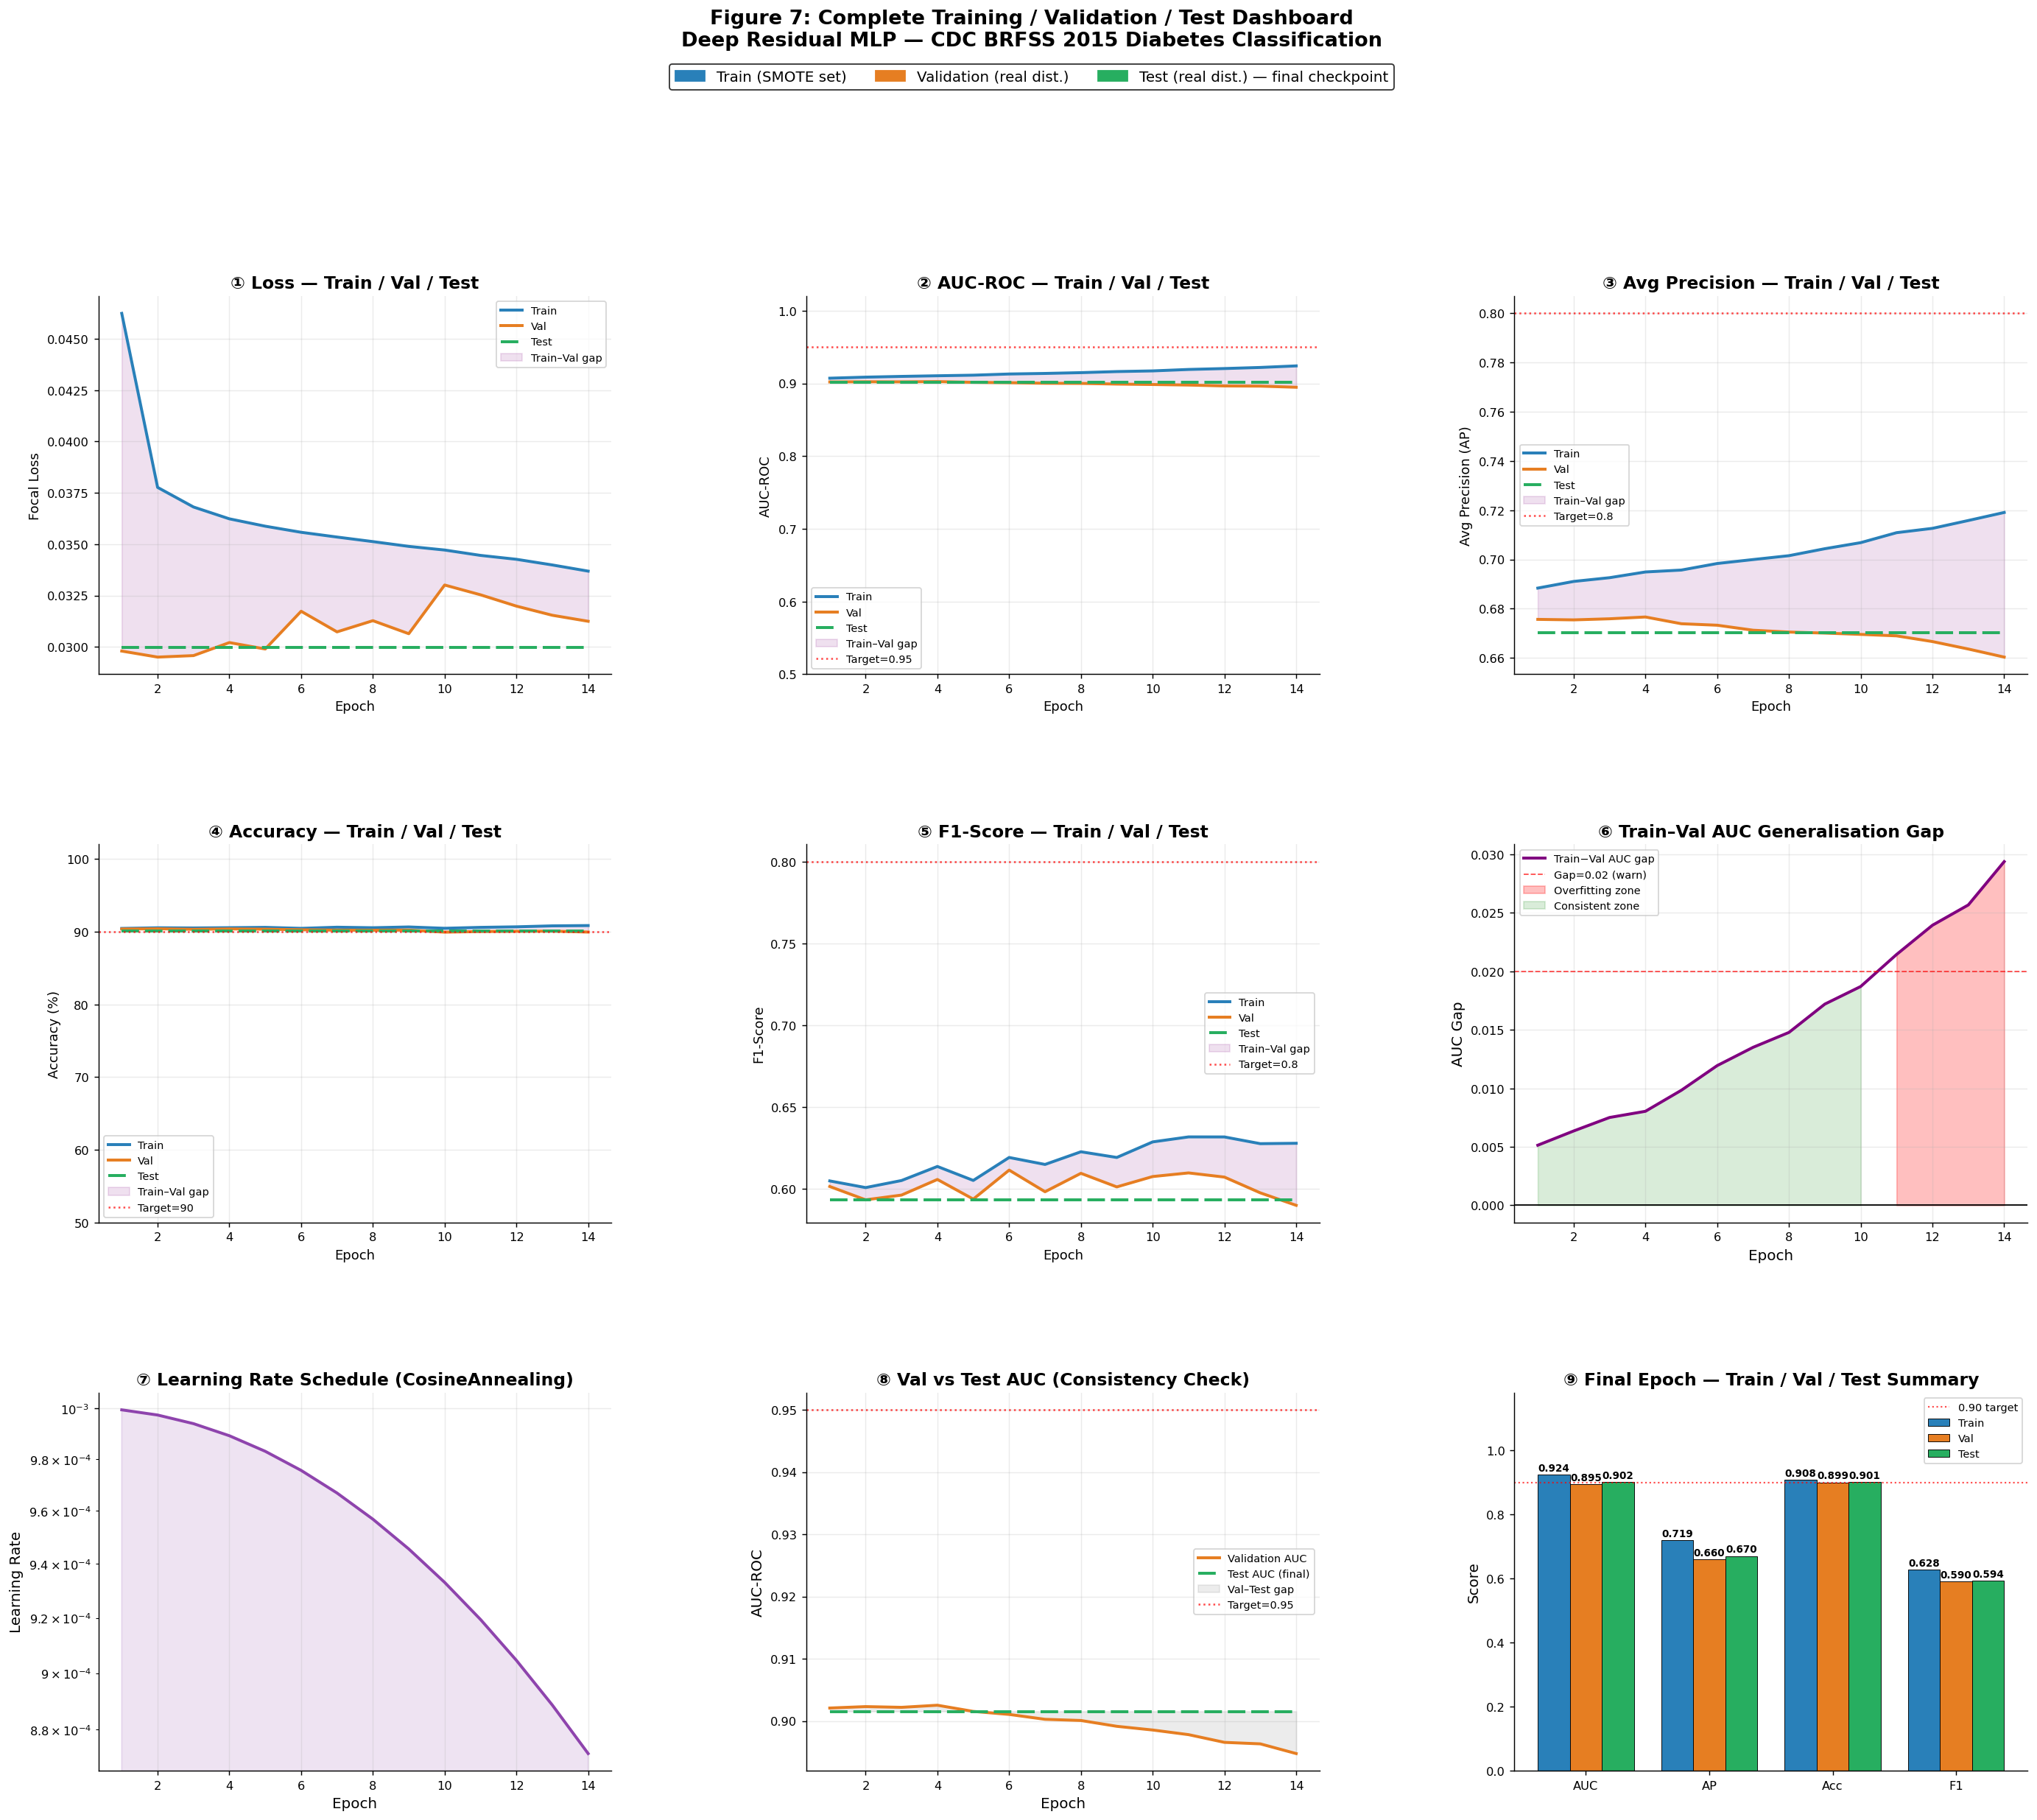


  Final epoch summary
   Train AUC : 0.9241
   Val   AUC : 0.8948
   Test  AUC : 0.9015
   Val–Test gap : 0.0068  < 0.02


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — FULL CURVE DASHBOARD (Train / Val / Test)
# ═══════════════════════════════════════════════════════════════
ep_r = np.arange(1, len(hist['tr_loss'])+1)

# Test is a horizontal line (single checkpoint value)
te_auc_line = np.full_like(ep_r, te['auc'], dtype=float)
te_ap_line  = np.full_like(ep_r, te['ap'],  dtype=float)
te_acc_line = np.full_like(ep_r, te['acc'], dtype=float)
te_f1_line  = np.full_like(ep_r, te['f1'],  dtype=float)
te_los_line = np.full_like(ep_r, te['loss'],dtype=float)

LW   = 2.2   # line width
FALP = 0.12  # fill alpha

fig = plt.figure(figsize=(26, 20))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

legend_patches = [
    mpatches.Patch(color=C_TRAIN, label='Train (SMOTE set)'),
    mpatches.Patch(color=C_VAL,   label='Validation (real dist.)'),
    mpatches.Patch(color=C_TEST,  label='Test (real dist.) — final checkpoint'),
]

# ── Helper ───────────────────────────────────────────────────
def plot_curve(ax, ep, tr_vals, vl_vals, te_vals,
               ylabel, title, target=None, ylim=None):
    ax.plot(ep, tr_vals, lw=LW, color=C_TRAIN, label='Train')
    ax.plot(ep, vl_vals, lw=LW, color=C_VAL,   label='Val')
    ax.plot(ep, te_vals, lw=LW, color=C_TEST,   label='Test',
            linestyle='--', dashes=(6,2))
    ax.fill_between(ep, tr_vals, vl_vals,
                    alpha=FALP, color='purple',
                    label='Train–Val gap')
    if target is not None:
        ax.axhline(target, color='red', ls=':', lw=1.4,
                   alpha=0.7, label=f'Target={target}')
    ax.set_xlabel('Epoch', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.25)
    if ylim: ax.set_ylim(ylim)

# ── (1,1) Focal Loss ─────────────────────────────────────────
ax = fig.add_subplot(gs[0,0])
plot_curve(ax, ep_r, hist['tr_loss'], hist['vl_loss'], te_los_line,
           'Focal Loss', '① Loss — Train / Val / Test')

# ── (1,2) AUC-ROC ────────────────────────────────────────────
ax = fig.add_subplot(gs[0,1])
plot_curve(ax, ep_r, hist['tr_auc'], hist['vl_auc'], te_auc_line,
           'AUC-ROC', '② AUC-ROC — Train / Val / Test', target=0.95, ylim=(0.5,1.02))

# ── (1,3) Avg Precision ──────────────────────────────────────
ax = fig.add_subplot(gs[0,2])
plot_curve(ax, ep_r, hist['tr_ap'], hist['vl_ap'], te_ap_line,
           'Avg Precision (AP)', '③ Avg Precision — Train / Val / Test', target=0.80)

# ── (2,1) Accuracy ───────────────────────────────────────────
ax = fig.add_subplot(gs[1,0])
plot_curve(ax, ep_r,
           [v*100 for v in hist['tr_acc']],
           [v*100 for v in hist['vl_acc']],
           te_acc_line*100,
           'Accuracy (%)', '④ Accuracy — Train / Val / Test',
           target=90, ylim=(50,102))

# ── (2,2) F1 Score ───────────────────────────────────────────
ax = fig.add_subplot(gs[1,1])
plot_curve(ax, ep_r, hist['tr_f1'], hist['vl_f1'], te_f1_line,
           'F1-Score', '⑤ F1-Score — Train / Val / Test', target=0.80)

# ── (2,3) Train–Val AUC gap ──────────────────────────────────
ax = fig.add_subplot(gs[1,2])
gap = np.array(hist['tr_auc']) - np.array(hist['vl_auc'])
ax.plot(ep_r, gap, lw=LW, color='purple', label='Train−Val AUC gap')
ax.axhline(0,    color='black', lw=1, ls='-')
ax.axhline(0.02, color='red',   lw=1, ls='--', alpha=0.7, label='Gap=0.02 (warn)')
ax.fill_between(ep_r, gap, 0, where=gap>0.02,
                alpha=0.25, color='red', label='Overfitting zone')
ax.fill_between(ep_r, gap, 0, where=gap<=0.02,
                alpha=0.15, color='green', label='Consistent zone')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC Gap')
ax.set_title('⑥ Train–Val AUC Generalisation Gap', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# ── (3,1) Learning rate schedule ─────────────────────────────
ax = fig.add_subplot(gs[2,0])
ax.plot(ep_r, hist['lr'], lw=LW, color='#8E44AD')
ax.fill_between(ep_r, 0, hist['lr'], alpha=0.15, color='#8E44AD')
ax.set_xlabel('Epoch'); ax.set_ylabel('Learning Rate')
ax.set_title('⑦ Learning Rate Schedule (CosineAnnealing)', fontweight='bold')
ax.grid(True, alpha=0.25)
ax.set_yscale('log')

# ── (3,2) Val vs Test AUC comparison ─────────────────────────
ax = fig.add_subplot(gs[2,1])
ax.plot(ep_r, hist['vl_auc'], lw=LW, color=C_VAL,  label='Validation AUC')
ax.plot(ep_r, te_auc_line,   lw=LW, color=C_TEST,
        ls='--', dashes=(6,2), label='Test AUC (final)')
ax.fill_between(ep_r, hist['vl_auc'], te_auc_line,
                alpha=0.15, color='gray', label='Val–Test gap')
ax.axhline(0.95, color='red', ls=':', lw=1.4, alpha=0.7, label='Target=0.95')
ax.set_xlabel('Epoch'); ax.set_ylabel('AUC-ROC')
ax.set_title('⑧ Val vs Test AUC (Consistency Check)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# ── (3,3) All splits summary bar ─────────────────────────────
ax = fig.add_subplot(gs[2,2])
metrics_summary = ['AUC', 'AP', 'Acc', 'F1']
tr_final = [hist['tr_auc'][-1], hist['tr_ap'][-1],
            hist['tr_acc'][-1], hist['tr_f1'][-1]]
vl_final = [hist['vl_auc'][-1], hist['vl_ap'][-1],
            hist['vl_acc'][-1], hist['vl_f1'][-1]]
te_final = [te['auc'], te['ap'], te['acc'], te['f1']]

x = np.arange(len(metrics_summary))
w = 0.26
b1 = ax.bar(x-w,   tr_final, w, label='Train', color=C_TRAIN, edgecolor='k', lw=0.5)
b2 = ax.bar(x,     vl_final, w, label='Val',   color=C_VAL,   edgecolor='k', lw=0.5)
b3 = ax.bar(x+w,   te_final, w, label='Test',  color=C_TEST,  edgecolor='k', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(metrics_summary)
ax.set_ylabel('Score'); ax.set_ylim(0, 1.18)
ax.axhline(0.90, color='red', ls=':', lw=1.2, alpha=0.7, label='0.90 target')
for bars in [b1,b2,b3]:
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.012,
                f'{b.get_height():.3f}', ha='center', fontsize=7.5, fontweight='bold')
ax.set_title('⑨ Final Epoch — Train / Val / Test Summary', fontweight='bold')
ax.legend(fontsize=8)

# ── Global legend + title ─────────────────────────────────────
fig.legend(handles=legend_patches, loc='upper center',
           bbox_to_anchor=(0.5, 1.005), ncol=3, fontsize=11,
           frameon=True, edgecolor='black')
plt.suptitle(
    'Figure 7: Complete Training / Validation / Test Dashboard\n'
    'Deep Residual MLP — CDC BRFSS 2015 Diabetes Classification',
    fontsize=15, fontweight='bold', y=1.03
)
plt.savefig('fig7_train_val_test_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()

final_gap = abs(hist['vl_auc'][-1] - te['auc'])
print(f'\n  Final epoch summary')
print(f'   Train AUC : {hist["tr_auc"][-1]:.4f}')
print(f'   Val   AUC : {hist["vl_auc"][-1]:.4f}')
print(f'   Test  AUC : {te["auc"]:.4f}')
print(f'   Val–Test gap : {final_gap:.4f}', ' < 0.02' if final_gap<0.02 else '> 0.02')

---
## 10. Threshold Optimisation for Clinical Use <a id='sec10'></a>

The **default 0.5 threshold is almost always wrong** for imbalanced clinical data.
We select the threshold that maximises clinical utility using two criteria:
1. **F1-optimal** — maximises harmonic mean of precision & recall  
2. **Sensitivity-targeted (≥0.80)** — ensures we catch ≥80% of diabetics (clinical priority)


Threshold at default 0.50 :
  Sensitivity=0.5187  Precision=0.7090  F1=0.5991 (often terrible for imbalanced)

Threshold F1-optimal = 0.4498 :
  Sensitivity=0.6240  Precision=0.6204  F1=0.6222

Threshold Sensitivity≥0.80 = 0.3497 :
  Sensitivity=0.8000  Precision=0.4345  F1=0.5631


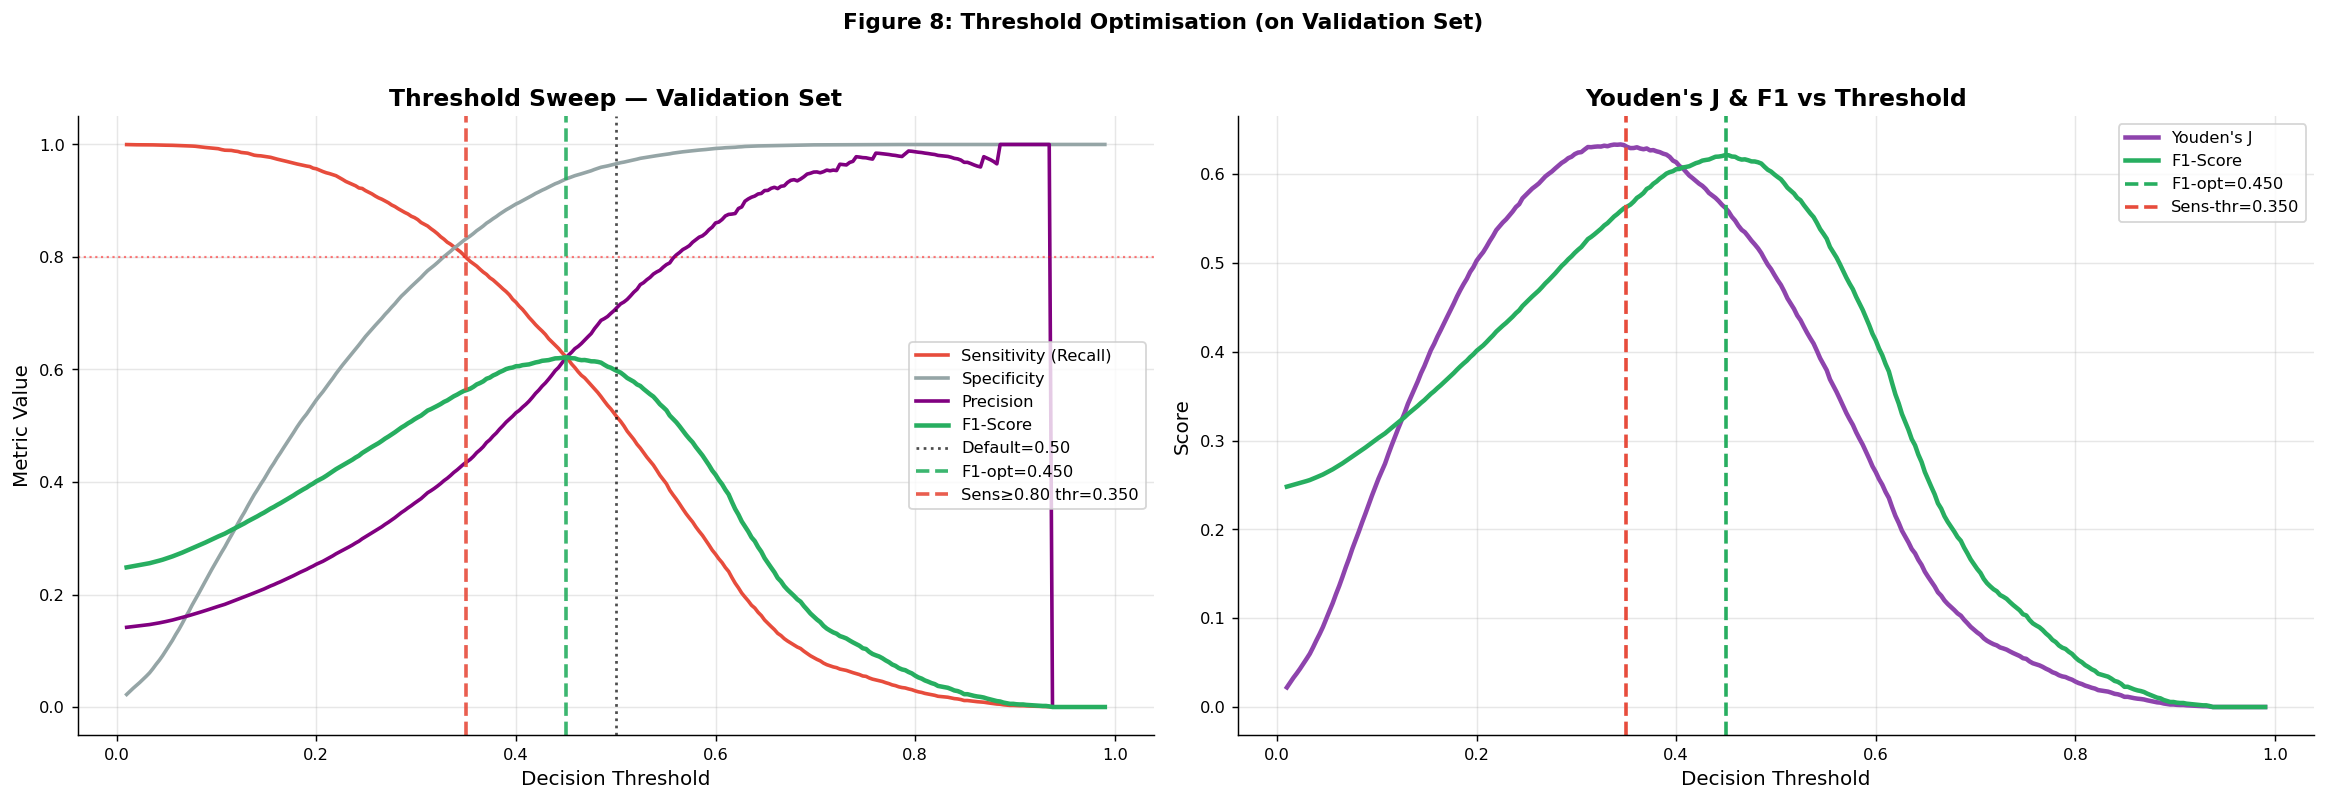


  Selected thresholds: F1-opt=0.4498  |  Sensitivity-targeted=0.3497


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — Threshold optimisation on VAL set
# ═══════════════════════════════════════════════════════════════
from sklearn.metrics import recall_score, precision_score # Moved import to the top

vl_res  = run_epoch(model, val_loader, optimizer, loss_fn, DEVICE, training=False)
vl_prob = vl_res['probs']
vl_lbl  = vl_res['labels']

prec_arr, rec_arr, thr_arr = precision_recall_curve(vl_lbl, vl_prob)
f1_arr  = 2*prec_arr*rec_arr / (prec_arr+rec_arr+1e-8)

# F1-optimal threshold
f1_idx    = np.argmax(f1_arr[:-1])   # skip last (undefined)
THR_F1    = float(thr_arr[f1_idx])

# Sensitivity-targeted: smallest threshold where sensitivity >= 0.80
fpr_v, tpr_v, thr_roc = roc_curve(vl_lbl, vl_prob)
sens_mask = tpr_v >= 0.80
THR_SENS  = float(thr_roc[sens_mask][0]) if sens_mask.any() else THR_F1

print(f'Threshold at default 0.50 :')
d05 = (vl_prob>=0.50).astype(int)
print(f'  Sensitivity={recall_score(vl_lbl,d05):.4f}  '  +
      f'Precision={precision_score(vl_lbl,d05):.4f}  '
      f'F1={f1_score(vl_lbl,d05):.4f}', '(often terrible for imbalanced)')

for name, thr in [('F1-optimal', THR_F1), ('Sensitivity≥0.80', THR_SENS)]:
    preds = (vl_prob>=thr).astype(int)
    print(f'\nThreshold {name} = {thr:.4f} :')
    print(f'  Sensitivity={recall_score(vl_lbl,preds):.4f}  '
          f'Precision={precision_score(vl_lbl,preds):.4f}  '
          f'F1={f1_score(vl_lbl,preds):.4f}')

# ── Threshold sweep plot ──────────────────────────────────────
thrs      = np.linspace(0.01, 0.99, 300)
sens_list, spec_list, f1_list, prec_list = [], [], [], []
for t in thrs:
    p  = (vl_prob>=t).astype(int)
    cm = confusion_matrix(vl_lbl, p)
    tn,fp,fn,tp = cm.ravel()
    sens_list.append(tp/(tp+fn+1e-8))
    spec_list.append(tn/(tn+fp+1e-8))
    f1_list.append(f1_score(vl_lbl, p, zero_division=0))
    prec_list.append(precision_score(vl_lbl, p, zero_division=0))

fig, axes = plt.subplots(1,2, figsize=(18,6))

axes[0].plot(thrs, sens_list,  lw=2, color=C_POS,   label='Sensitivity (Recall)')
axes[0].plot(thrs, spec_list,  lw=2, color=C_NEG,   label='Specificity')
axes[0].plot(thrs, prec_list,  lw=2, color='purple', label='Precision')
axes[0].plot(thrs, f1_list,    lw=2.5,color=C_TEST,  label='F1-Score')
axes[0].axvline(0.50,    color='black', ls=':',  lw=1.5, alpha=0.7, label='Default=0.50')
axes[0].axvline(THR_F1,  color=C_TEST,  ls='--', lw=2,   alpha=0.9, label=f'F1-opt={THR_F1:.3f}')
axes[0].axvline(THR_SENS,color=C_POS,   ls='--', lw=2,   alpha=0.9, label=f'Sens≥0.80 thr={THR_SENS:.3f}')
axes[0].axhline(0.80, color='red', ls=':', lw=1.2, alpha=0.5)
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Metric Value')
axes[0].set_title('Threshold Sweep — Validation Set', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Youden's J = Sensitivity + Specificity - 1
youdens = np.array(sens_list) + np.array(spec_list) - 1
axes[1].plot(thrs, youdens, lw=2.5, color='#8E44AD', label="Youden's J")
axes[1].plot(thrs, f1_list, lw=2.5, color=C_TEST,    label='F1-Score')
axes[1].axvline(THR_F1,  color=C_TEST,  ls='--', lw=2, label=f'F1-opt={THR_F1:.3f}')
axes[1].axvline(THR_SENS,color=C_POS,   ls='--', lw=2, label=f'Sens-thr={THR_SENS:.3f}')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Score')
axes[1].set_title("Youden's J & F1 vs Threshold", fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 8: Threshold Optimisation (on Validation Set)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig8_threshold_optimisation.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'\n  Selected thresholds: F1-opt={THR_F1:.4f}  |  Sensitivity-targeted={THR_SENS:.4f}')

> **Interpretation.** The default 0.5 threshold catches only about half of positive cases (validation sensitivity 0.519). The F1-optimal threshold (0.450) balances precision and recall at about 0.62 each, while a screening threshold of 0.350 meets the clinical target of **80% sensitivity** at the cost of lower precision (0.43). Both thresholds are chosen on validation data only, then applied unchanged to the test set in Section 11.

---

[← Residual MLP & Depth × Width Ablation](02_model_and_depth_width_ablation.ipynb) · [Next: Evaluation, Explainability & Consistency Audit →](04_evaluation_and_explainability.ipynb)